In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\BHUVAN\OneDrive\Desktop\BOOKs & pdfs\B.Tech_3rd_Year\Sem-5_M26\IICT_Internship\Titanic\train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
X = df[['Age', 'Pclass', 'Sex']]
y = df['Survived']

X['Age'] = X['Age'].fillna(X['Age'].mean())
X['Sex'] = X['Sex'].map({'male':0, 'female':1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Supervised Learning (Logistic Regression)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Supervised Learning (Logistic Regression)
Accuracy: 0.8100558659217877
Confusion Matrix:
 [[91 14]
 [20 54]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179




Unsupervised Learning (K-Means Clustering)
Cluster Centers:
 [[ 28.63774227  15.45395432   2.55144033]
 [ 31.01991176 279.308545     1.        ]
 [ 34.96198219  83.39327958   1.24647887]]


C:\Users\BHUVAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


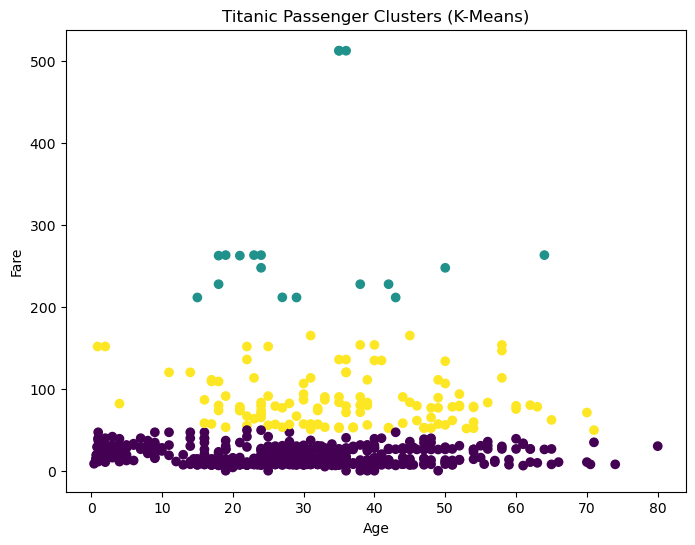

In [5]:
X_cluster = df[['Age', 'Fare', 'Pclass']].fillna(df[['Age','Fare','Pclass']].mean())

k_means = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = k_means.fit_predict(X_cluster)

print("\nUnsupervised Learning (K-Means Clustering)")
print("Cluster Centers:\n", k_means.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(df['Age'], df['Fare'], c=df['Cluster'], cmap='viridis')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Titanic Passenger Clusters (K-Means)")
plt.show()